In [1]:
# Smoke test: PreparedSubject shared across both conditions for Sub2, plus
# full-trial mode + windowed mode, confirming no cross-condition aliasing.
from config import load_config
import utils
import pretty_midi
import yaml
import numpy as np
import pandas as pd
import torch

from dataset import PreparedSubject, TRFDataset

config = load_config()
subject = 'Sub2'
eeg_path = config.paths.eeg_dir / config.eeg_filename_pattern.format(subject=subject)
eeg_data = utils.load_subject_raw_eeg(eeg_path, subject)

prepared = PreparedSubject(subject, eeg_data, config, debug=True)

## ── both conditions share the same PreparedSubject (steps 1-6 run once) ──
ds_acoustic = prepared.to_dataset('acoustic', window_samples=None)
ds_full = prepared.to_dataset('acoustic_and_surprisal', window_samples=None)
# assert ds_acoustic.events is ds_full.events is prepared.events, \
    # "both conditions should share the same PreparedSubject.events object"
assert ds_acoustic.trials is not ds_full.trials
# 'acoustic' only z-scores 2 features; 'acoustic_and_surprisal' z-scores 6.
assert set(ds_acoustic.trials[0].keys()) == {'eeg', 'envelope', 'onsets'}
assert set(ds_full.trials[0].keys()) == {
    'eeg', 'envelope', 'onsets', 'pitch_surprisal', 'pitch_entropy',
    'onset_surprisal', 'onset_entropy'}
# calling to_dataset twice must not have mutated prepared._trials_raw in a
# way that cross-contaminates: envelope z-scored the same way in both.
assert np.allclose(ds_acoustic.trials[0]['envelope'], ds_full.trials[0]['envelope'])
print("[PreparedSubject] shared events, independent per-condition trials: OK")

assert len(ds_full) == len(ds_full.trial_lengths) == ds_full.n_trials
X0, Y0 = ds_full[0]
T0 = ds_full.trial_lengths[0]
assert X0.shape == (len(ds_full.feature_keys), T0), (X0.shape, T0)
assert Y0.shape == (ds_full.n_channels, T0), (Y0.shape, T0)
assert X0.dtype == torch.float32 and Y0.dtype == torch.float32
print(f"[full-trial] len(ds)={len(ds_full)} == n_trials, "
        f"ds[0] X{tuple(X0.shape)} Y{tuple(Y0.shape)} float32: OK")

# ── windowed mode, derived from the SAME prepared subject ──
ws, hs = 64, 64
ds_win = prepared.to_dataset('acoustic_and_surprisal', window_samples=ws, hop_samples=hs)
manual = sum(max(0, (T - ws) // hs + 1) for T in ds_win.trial_lengths)
assert len(ds_win) == manual == len(ds_win.window_trial_indices), (len(ds_win), manual)
Xw, Yw = ds_win[0]
assert Xw.shape == (len(ds_win.feature_keys), ws)
assert Yw.shape == (ds_win.n_channels, ws)
assert Xw.dtype == torch.float32 and Yw.dtype == torch.float32
for ti in range(ds_win.n_trials):
    idxs = ds_win.windows_for_trial(ti)
    assert all(ds_win.window_trial_indices[j] == ti for j in idxs)
total = sum(len(ds_win.windows_for_trial(ti)) for ti in range(ds_win.n_trials))
assert total == len(ds_win)
print(f"[windowed]  len(ds)={len(ds_win)} == manual window count, "
        f"ds[0] X{tuple(Xw.shape)} Y{tuple(Yw.shape)} float32, "
        f"windows_for_trial consistent: OK")

# ── TRFDataset's direct constructor still works (builds its own throwaway
# PreparedSubject internally) ──
ds_direct = TRFDataset(subject, eeg_data, 'acoustic', config, window_samples=int(2.0*64))
assert np.allclose(ds_direct.trials[0]['eeg'], ds_acoustic.trials[0]['eeg'])
print("[direct constructor] TRFDataset(...) still works standalone: OK")

print("SMOKE TEST PASSED")


✓ Loaded raw EEG (Sub2): 30 trials, 64 channels @ 512 Hz
  [pre] Trial 1: raw = 82395 samples @ 512 Hz  (pad = 512 samples)
  [pre] Trial 1: post-preproc = 10236 samples @ 64 Hz
  [pre] Trial 2: raw = 79891 samples @ 512 Hz  (pad = 512 samples)
  [pre] Trial 2: post-preproc = 9923 samples @ 64 Hz
  [pre] Trial 3: raw = 62544 samples @ 512 Hz  (pad = 512 samples)
  [pre] Trial 3: post-preproc = 7754 samples @ 64 Hz
  [pre] Trial 4: raw = 70553 samples @ 512 Hz  (pad = 512 samples)
  [pre] Trial 4: post-preproc = 8756 samples @ 64 Hz
  [pre] Trial 5: raw = 85879 samples @ 512 Hz  (pad = 512 samples)
  [pre] Trial 5: post-preproc = 10671 samples @ 64 Hz
  [pre] Trial 6: raw = 103070 samples @ 512 Hz  (pad = 512 samples)
  [pre] Trial 6: post-preproc = 12820 samples @ 64 Hz
  [pre] Trial 7: raw = 89690 samples @ 512 Hz  (pad = 512 samples)
  [pre] Trial 7: post-preproc = 11148 samples @ 64 Hz
  [pre] Trial 8: raw = 94316 samples @ 512 Hz  (pad = 512 samples)
  [pre] Trial 8: post-preproc =

/Users/arianapereira/miniconda3/envs/eelbrain-env/lib/python3.11/site-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


[PreparedSubject] shared events, independent per-condition trials: OK
[full-trial] len(ds)=30 == n_trials, ds[0] X(6, 10172) Y(64, 10172) float32: OK
[windowed]  len(ds)=4794 == manual window count, ds[0] X(6, 64) Y(64, 64) float32, windows_for_trial consistent: OK
[direct constructor] TRFDataset(...) still works standalone: OK
SMOKE TEST PASSED


Columns in the trials_raw list: dict_keys(['eeg', 'envelope', 'onsets', 'pitch_surprisal', 'pitch_entropy', 'onset_surprisal', 'onset_entropy'])
Number of trials for each subject: 30
Number of samples in the first trial: 10172
Number of channels for each sample: 64


Text(0.5, 1.0, 'Raw EEG of Sub2 and Trial 1')

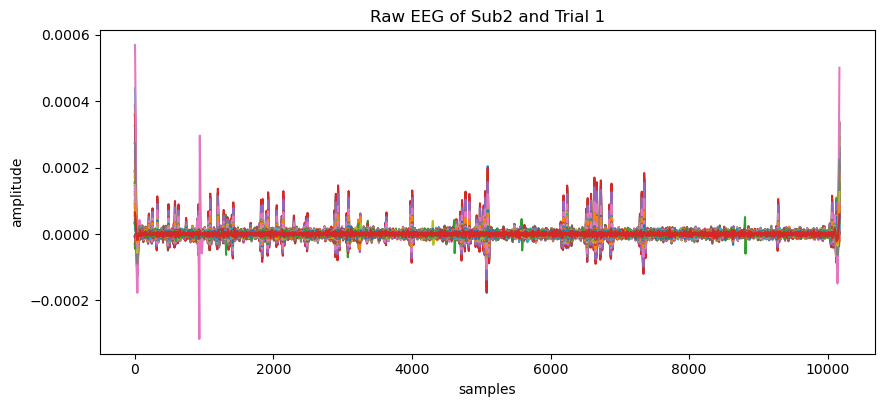

In [2]:
import matplotlib.pyplot as plt

ex_trial = 0 

print(prepared)
print("Columns in the trials_raw list:", prepared._trials_raw[0].keys())
print("Number of trials for each subject:",len(prepared._trials_raw))
print("Number of samples in the first trial:",len(prepared._trials_raw[ex_trial]['eeg']))
print("Number of channels for each sample:",len(prepared._trials_raw[ex_trial]['eeg'][0]))

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(prepared._trials_raw[0]['eeg'])
ax.set_xlabel('samples')
ax.set_ylabel('amplitude')
ax.set_title(f"Raw EEG of {subject} and Trial {ex_trial+1}")


In [68]:
print("Understanding the shapes and data contained in ds_full", ds_full)
print("Columns in the events table:", ds_full.events[0].keys())
print("Columns in the trials list:", ds_full.trials[0].keys())
print("Number of trials for each subject:",len(ds_full.trials))
print("Number of samples in the first trial:",len((ds_full.trials[0]['eeg'])))
print("Number of channels for each sample:",len((ds_full.trials[0]['eeg'][0])))
ds_full.events


Understanding the shapes and data contained in ds_full <dataset.TRFDataset object at 0x17fd39590>
Columns in the events table: dict_keys(['i_start', 'trigger', 'event', 'envelope', 'onsets', 'duration', 'eeg', 'pitch_surprisal', 'pitch_entropy', 'onset_surprisal', 'onset_entropy'])
Columns in the trials list: dict_keys(['eeg', 'envelope', 'onsets', 'pitch_surprisal', 'pitch_entropy', 'onset_surprisal', 'onset_entropy'])
Number of trials for each subject: 30
Number of samples in the first trial: 10172
Number of channels for each sample: 64


#,i_start,trigger,event,envelope,onsets,duration,eeg,pitch_surprisal,pitch_entropy,onset_surprisal,onset_entropy
0,1,1,1,<NDVar: 1017...,<NDVar: 1017...,158.94,<NDVar: 64 s...,<NDVar 'pitc...,<NDVar 'pitc...,<NDVar 'onse...,<NDVar 'onse...
1,10236,2,2,<NDVar: 9859...,<NDVar: 9859...,154.05,<NDVar: 64 s...,<NDVar 'pitc...,<NDVar 'pitc...,<NDVar 'onse...,<NDVar 'onse...
2,20159,3,3,<NDVar: 7690...,<NDVar: 7690...,120.16,<NDVar: 64 s...,<NDVar 'pitc...,<NDVar 'pitc...,<NDVar 'onse...,<NDVar 'onse...
3,27913,4,4,<NDVar: 8692...,<NDVar: 8692...,135.81,<NDVar: 64 s...,<NDVar 'pitc...,<NDVar 'pitc...,<NDVar 'onse...,<NDVar 'onse...
4,36669,5,5,<NDVar: 1060...,<NDVar: 1060...,165.73,<NDVar: 64 s...,<NDVar 'pitc...,<NDVar 'pitc...,<NDVar 'onse...,<NDVar 'onse...
5,47340,6,6,<NDVar: 1275...,<NDVar: 1275...,199.31,<NDVar: 64 s...,<NDVar 'pitc...,<NDVar 'pitc...,<NDVar 'onse...,<NDVar 'onse...
6,60160,7,7,<NDVar: 1108...,<NDVar: 1108...,173.19,<NDVar: 64 s...,<NDVar 'pitc...,<NDVar 'pitc...,<NDVar 'onse...,<NDVar 'onse...
7,71308,8,8,<NDVar: 1166...,<NDVar: 1166...,182.22,<NDVar: 64 s...,<NDVar 'pitc...,<NDVar 'pitc...,<NDVar 'onse...,<NDVar 'onse...
8,83034,9,9,<NDVar: 8588...,<NDVar: 8588...,134.19,<NDVar: 64 s...,<NDVar 'pitc...,<NDVar 'pitc...,<NDVar 'onse...,<NDVar 'onse...
9,91686,10,10,<NDVar: 1139...,<NDVar: 1139...,178.11,<NDVar: 64 s...,<NDVar 'pitc...,<NDVar 'pitc...,<NDVar 'onse...,<NDVar 'onse...


Text(0.5, 1.0, 'Z-scored EEG of Sub2 and Trial 1')

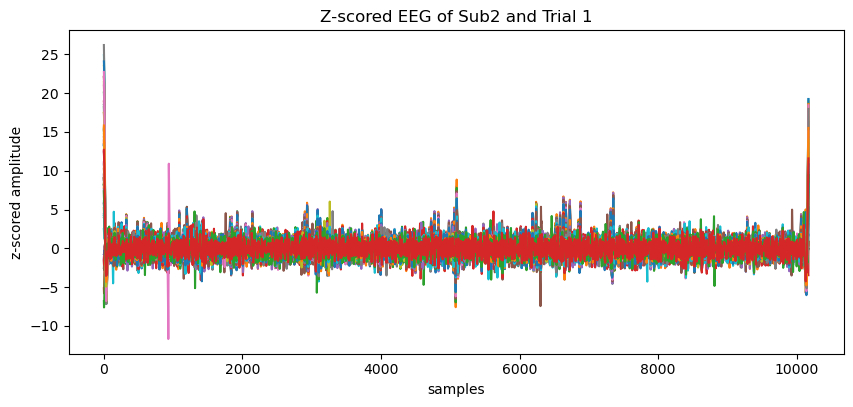

In [4]:
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(ds_full.trials[0]['eeg'])
ax.set_xlabel('samples')
ax.set_ylabel('z-scored amplitude')
ax.set_title(f"Z-scored EEG of {subject} and Trial {ex_trial+1}")


In [5]:
ds_direct = TRFDataset(
    subject, 
    eeg_data, 
    'acoustic', 
    config, 
    window_samples=7*64, 
    # hop_samples=6*64
    ) 

## figure out where to put hopside and fi its posible to hid eeg_data and make it a input as which dataset you need 

In [6]:
## figure out what 675 means? why this size??

print(len(ds_direct))
print(ds_direct.feature_set)


675
acoustic


In [111]:
config = load_config()
subject = 'Sub2'
eeg_path = config.paths.eeg_dir / config.eeg_filename_pattern.format(subject=subject)
eeg_data = utils.load_subject_raw_eeg(eeg_path, subject)

acoustic_ds = TRFDataset(
    subject, 
    eeg_data, 
    'acoustic',
    config, 
    window_samples=7*64,
    hop_samples=6*64
    )

acoustic_and_surprisal_ds = TRFDataset(
    subject, 
    eeg_data, 
    'acoustic_and_surprisal',
    config, 
    window_samples=7*64,
    hop_samples=6*64
    )

✓ Loaded raw EEG (Sub2): 30 trials, 64 channels @ 512 Hz


# Examine Experiment Results

In [18]:
import pickle
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import fdrcorrection
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

import eelbrain
from eelbrain import combine


In [19]:
# Make sure your environment is set up (conda activate eelbrain-env and source musical-surprisal/TRF/.venv/bin/activate)

# ! python experiments/TRF_sklearn.py
# ! python experiments/TRF_boosting.py
# ! python experiments/TRF_mne.py
# ! python experiments/TRF_conv_2_windowed.py

In [95]:
sklearn_data_acoustic = eelbrain.load.unpickle(f"results/encoding_2026-07-16/Sub1__sklearn_ridge__acoustic.pkl")
sklearn_data_acoustic.keys()

dict_keys(['meta', 'r_per_channel', 'per_trial_r', 'Y_pred', 'Y_true', 'weights', 'alpha_selection', 'training_history'])

In [ ]:
print("\nResults")
print("-"*64)


print("per_trial_r shape:", sklearn_data_acoustic['per_trial_r'].shape, "= (n_trials, n_channels)")
print("r_per_channel type:", type(sklearn_data_acoustic['r_per_channel']), "and shape:", sklearn_data_acoustic['r_per_channel'].shape)
# r_per_channel is the pearson's correlation over all the trials concatenated (for every channel = pearsonr(Y_true, Y_pred))
# per_trial_r is the pearson's correlation computed per trial and per channel 

print("Y_pred shape:", sklearn_data_acoustic['Y_pred'].shape, "= (n_samples, n_channels)")
print("Y_true shape:", sklearn_data_acoustic['Y_true'].shape, "= (n_samples, n_channels)")
# 307527 is the total number of samples which are when actual EEG is being recorded. 
# There is a buffer 1 second (64 samples) in between each trial which is why the total sample_id is higher 

print("\nModel Dependent Results")
print("-"*64)
print("weights shape:", sklearn_data_acoustic['weights'].shape, "= (n_channels, n_lags, n_features)")
print("alpha_selection type:", type(sklearn_data_acoustic['alpha_selection']), " Ridge model only {alpha: mean_cv_r}")
print("training_history type:", type(sklearn_data_acoustic['training_history']), "Conv model only dict of per-epoch arrays")


Results
----------------------------------------------------------------
per_trial_r shape: (30, 64) = (n_trials, n_channels)
r_per_channel type: <class 'numpy.ndarray'> and shape: (64,)
Y_pred shape: (307527, 64) = (n_samples, n_channels)
Y_true shape: (307527, 64) = (n_samples, n_channels)

Model Dependent Results
----------------------------------------------------------------
weights shape: (64, 46, 2) = (n_channels, n_lags, n_features)
alpha_selection type: <class 'dict'>  Ridge model only {alpha: mean_cv_r}
training_history type: <class 'NoneType'> Conv model only dict of per-epoch arrays


In [12]:
def permutation_test(a, b, n_permutations=10000, two_tailed=True, seed=42):
    """Sign-flip permutation test for paired data."""
    rng = np.random.default_rng(seed)
    diff = b - a
    observed = diff.mean()
    
    count = 0
    for _ in range(n_permutations):
        signs = rng.choice([-1, 1], size=len(diff))
        perm_mean = (signs * diff).mean()
        if two_tailed:
            count += abs(perm_mean) >= abs(observed)
        else:
            count += perm_mean >= observed
    
    p_val = count / n_permutations
    return observed, p_val


In [21]:
def plot(n_subjects, pickle_folder, model):
    # ── 1. Load all subjects ──────────────────────────────────────────────────────
    n_subjects = n_subjects
    r_acoustic_all = []  # will be shape (n_subjects, n_channels)
    r_full_all     = []

    for sub in range(1, n_subjects + 1):
        try:
            data_acoustic = eelbrain.load.unpickle(f"results/{pickle_folder}/Sub{sub}__{model}__acoustic.pkl")
            data_full     = eelbrain.load.unpickle(f"results/{pickle_folder}/Sub{sub}__{model}__acoustic_and_surprisal.pkl")

            r_acoustic_all.append(data_acoustic['r_per_channel'])
            r_full_all.append(data_full['r_per_channel'])
            print(f"  Sub{sub:02d} loaded")

        except FileNotFoundError:
            print(f"  Sub{sub:02d} missing — skipping")

    r_acoustic_all = np.array(r_acoustic_all)  # (n_subjects, n_channels)
    r_full_all     = np.array(r_full_all)
    n_subjects     = len(r_acoustic_all)       # update in case any were skipped

    print(f"\nLoaded {n_subjects} subjects, {r_acoustic_all.shape[0]} channels each")

    # ── 2. Per-subject mean r (averaged across channels) ─────────────────────────
    r_acoustic_per_sub = r_acoustic_all.mean(axis=1)  # (n_subjects,)
    r_full_per_sub     = r_full_all.mean(axis=1)
    r_diff_per_sub     = r_full_per_sub - r_acoustic_per_sub

    # ── 3. Group-level statistics — two-tailed sign-flip permutation test ─────────
    mean_diff, p_val = permutation_test(r_acoustic_per_sub, r_full_per_sub,
                                        n_permutations=10000, two_tailed=True)
    sem_diff = r_diff_per_sub.std() / np.sqrt(n_subjects)

    # Per-channel permutation test across subjects + FDR correction
    n_channels    = r_acoustic_all.shape[0]
    p_per_channel = np.array([
        permutation_test(r_acoustic_all[:, ch], r_full_all[:, ch],
                        n_permutations=10000, two_tailed=True)[1]
        for ch in range(n_channels)
    ])
    _, p_fdr = fdrcorrection(p_per_channel)

    sig_label = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
    print(f"\nGroup-level permutation test (mean r across channels):")
    print(f"  p = {p_val:.4f}  {sig_label}")
    print(f"  Mean Δr = {mean_diff:.4f} ± {sem_diff:.4f} SEM")
    print(f"  Channels significant after FDR (p<0.05): {(p_fdr < 0.05).sum()} / {n_channels}")


    # ── 4. Figure 1 – Violin: group-level acoustic vs full ───────────────────────
    fig, ax = plt.subplots(figsize=(7, 6))

    data   = [r_acoustic_per_sub, r_full_per_sub]
    labels = ['Acoustic\n(envelope)', 'Full\n(+ onsets + surprisal + entropy)']
    colors = ['steelblue', 'darkorange']

    parts = ax.violinplot(data, positions=[1, 2], showmedians=False, showextrema=False)
    for pc, color in zip(parts['bodies'], colors):
        pc.set_facecolor(color)
        pc.set_alpha(0.6)

    # Individual subject points connected by lines
    for i in range(n_subjects):
        ax.plot([1, 2], [r_acoustic_per_sub[i], r_full_per_sub[i]],
                color='gray', alpha=0.4, linewidth=0.8)
        # ax.text(1-0.08,r_acoustic_per_sub[i], f'{r_acoustic_per_sub[i]:.4f}', 
        #         fontsize=8, va='center', ha='right', alpha=0.7)
        # ax.text(2 + 0.08, r_full_per_sub[i], f'{r_full_per_sub[i]:.4f}', 
        #         fontsize=8, va='center', ha='left', alpha=0.7)
        
    for i, (d, color) in enumerate(zip(data, colors), start=1):
        jitter = np.random.uniform(-0.04, 0.04, size=len(d))
        ax.scatter(i + jitter, d, color=color, s=40, alpha=0.8,
                edgecolors='white', linewidths=0.5, zorder=4)

    # Mean ± SEM
    for i, d in enumerate(data, start=1):
        mean_val = d.mean()
        
        ax.errorbar(i, mean_val, yerr=d.std() / np.sqrt(len(d)),
                    fmt='o', color='black', markersize=7, capsize=5, linewidth=2, zorder=5)
        ax.text(i + 0.08, mean_val, f'Mean: {mean_val:.4f}', 
                color='black', fontsize=10, fontweight='bold', va='center', ha='left', zorder=6)

    # Significance bracket
    y_bracket = max(r_acoustic_per_sub.max(), r_full_per_sub.max()) + 0.005
    ax.plot([1, 1, 2, 2], [y_bracket - 0.003, y_bracket, y_bracket, y_bracket - 0.003],
            color='black', linewidth=1.2)
    ax.text(1.5, y_bracket + 0.003, f'p = {p_val:.4f}  {sig_label}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax.set_xticks([1, 2])
    ax.set_xticklabels(labels, fontsize=11)
    ax.set_ylabel('Mean CV Correlation (r)', fontsize=12)
    ax.set_title(f'Group-Level Encoding Correlation\n(N = {n_subjects} subjects)', fontsize=13)
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_xlim(0.4, 2.6)
    plt.tight_layout()
    # plt.savefig('group_violin.png', dpi=150)
    plt.show()

    # ── 5. Figure 2 – Per-subject Δr bar chart ───────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 4))
    sub_labels = [f'Sub{i+1:02d}' for i in range(n_subjects)]
    colors_bar = ['seagreen' if d > 0 else 'crimson' for d in r_diff_per_sub]

    ax.bar(range(n_subjects), r_diff_per_sub, color=colors_bar, alpha=0.8, edgecolor='white')
    ax.axhline(0,         color='gray',  linewidth=0.8)
    ax.axhline(mean_diff, color='black', linewidth=1.5, linestyle='--',
            label=f'Group mean Δr = {mean_diff:.4f}')
    ax.set_xticks(range(n_subjects))
    ax.set_xticklabels(sub_labels, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Δr (full − acoustic)')
    ax.set_title('Per-Subject Improvement from Adding Surprisal + Entropy\n(green = improvement, red = worse)')
    ax.legend()
    plt.tight_layout()
    # plt.savefig('group_delta_r_per_subject.png', dpi=150)
    plt.show()

    # ── 6. Figure 3 – Per-channel group Δr with FDR-corrected significance ───────
    r_diff_per_channel = (r_full_all - r_acoustic_all).mean(axis=0)  # (n_channels,)
    channel_names      = data_full['meta']['channel_names']

    fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

    # Top: mean Δr per channel
    colors_ch = ['seagreen' if d > 0 else 'crimson' for d in r_diff_per_channel]
    axes[0].bar(range(n_channels), r_diff_per_channel, color=colors_ch, alpha=0.8, edgecolor='white')
    axes[0].axhline(0, color='gray', linewidth=0.8)
    axes[0].axhline(r_diff_per_channel.mean(), color='black', linestyle='--', linewidth=1.2,
                    label=f'Mean = {r_diff_per_channel.mean():.4f}')
    axes[0].set_ylabel('Mean Δr across subjects')
    axes[0].set_title('Per-Channel Group Δr (full − acoustic)')
    axes[0].legend()

    # Bottom: -log10(p_fdr) per channel with significance threshold line
    neg_log_p_fdr = -np.log10(np.maximum(p_fdr, 1e-10))
    axes[1].bar(range(n_channels), neg_log_p_fdr, color='mediumpurple', alpha=0.8, edgecolor='white')
    axes[1].axhline(-np.log10(0.05), color='red',    linestyle='--', linewidth=1.2, label='FDR p = 0.05')
    axes[1].axhline(-np.log10(0.01), color='orange', linestyle='--', linewidth=1.2, label='FDR p = 0.01')
    axes[1].set_ylabel('−log₁₀(p_FDR)')
    axes[1].set_title('Per-Channel Significance of Improvement (FDR-corrected permutation test)')
    axes[1].set_xticks(range(n_channels))
    axes[1].set_xticklabels(channel_names, rotation=90, fontsize=7)
    axes[1].legend()

    plt.tight_layout()
    # plt.savefig('group_per_channel.png', dpi=150)
    plt.show()

  Sub01 loaded

Loaded 1 subjects, 1 channels each

Group-level permutation test (mean r across channels):
  p = 1.0000  ns
  Mean Δr = 0.0017 ± 0.0000 SEM
  Channels significant after FDR (p<0.05): 0 / 1


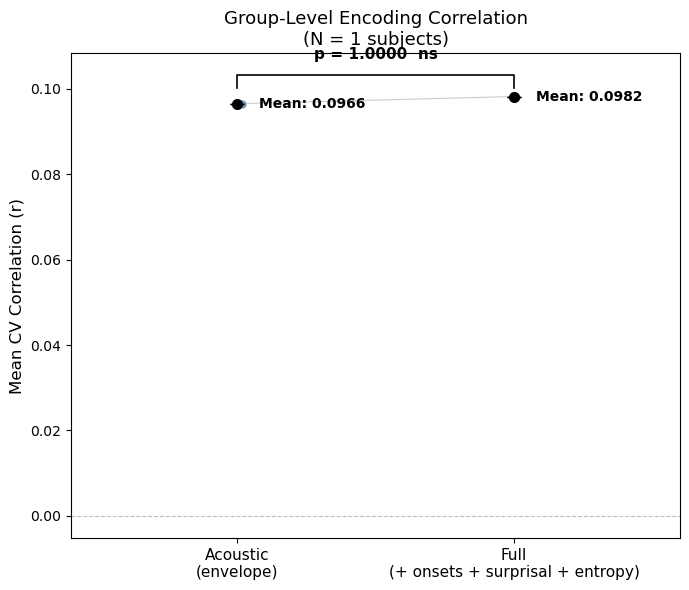

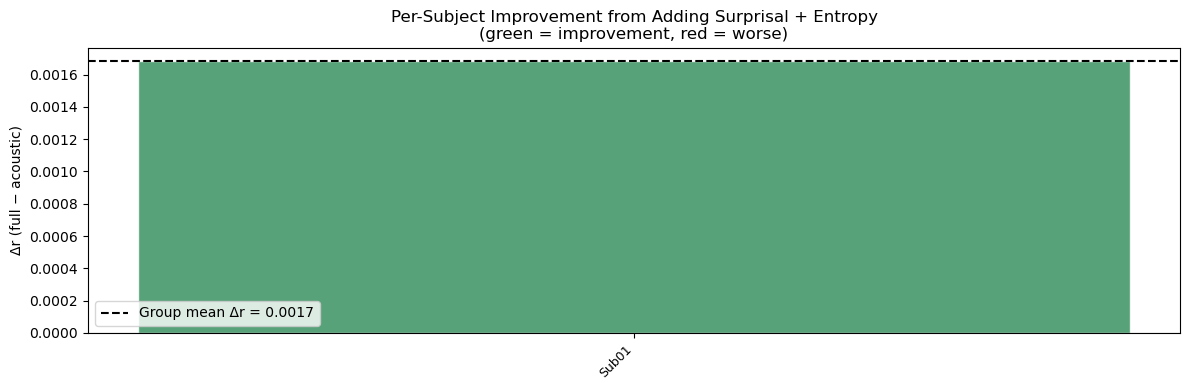

ValueError: The number of FixedLocator locations (1), usually from a call to set_ticks, does not match the number of labels (64).

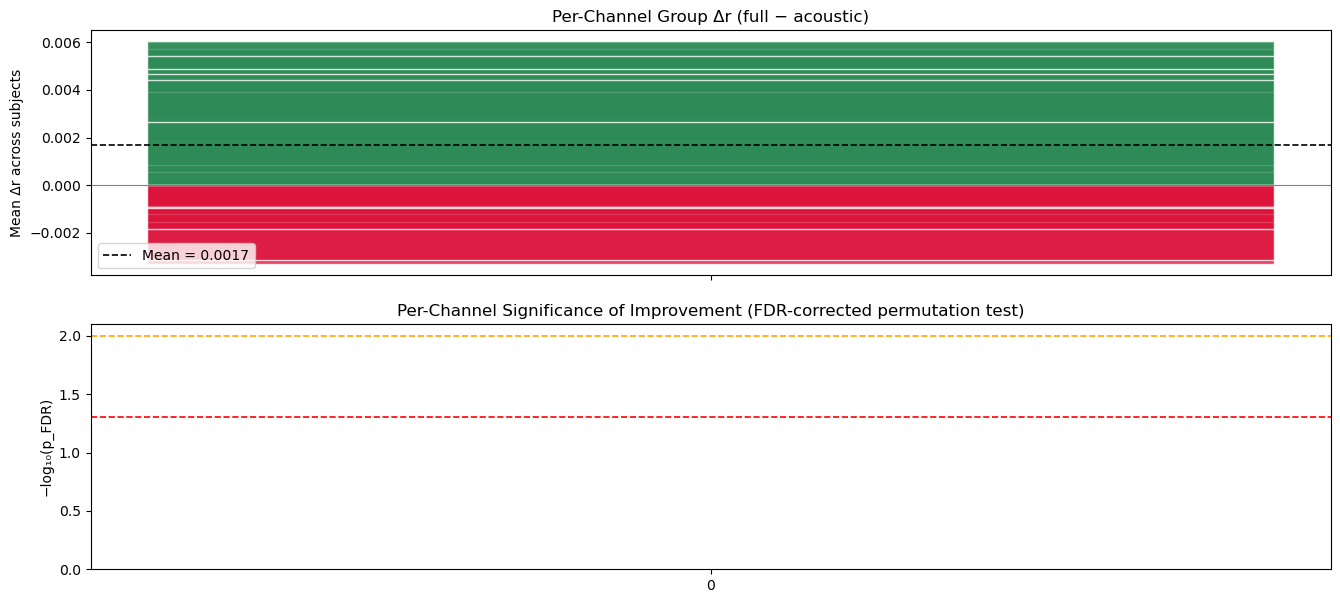

In [106]:
n_subjects = 1
pickle_folder = 'encoding_2026-07-09'
model = 'sklearn_ridge'

plot(n_subjects, pickle_folder, model)

In [112]:
n_subjects = 1
pickle_folder = 'encoding_2026-07-06'
model = 'boosting'

plot(n_subjects, pickle_folder, model)

  Sub01 missing — skipping

Loaded 0 subjects, 0 channels each


AxisError: axis 1 is out of bounds for array of dimension 1

  Sub01 loaded

Loaded 1 subjects, 64 channels each

Group-level permutation test (mean r across channels):
  p = 1.0000  ns
  Mean Δr = -0.0588 ± 0.0000 SEM
  Channels significant after FDR (p<0.05): 0 / 64


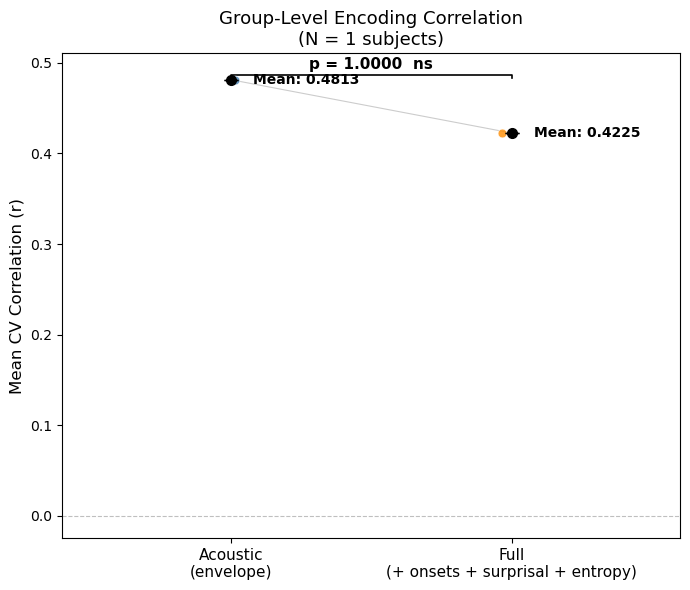

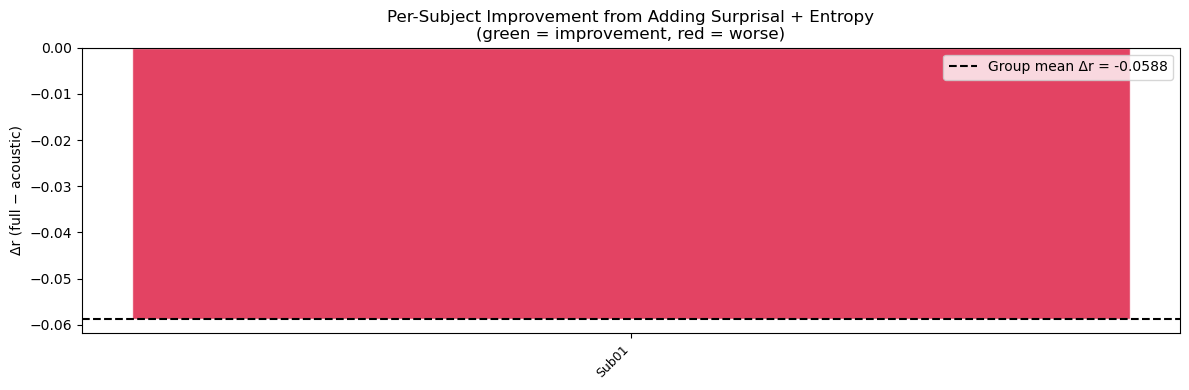

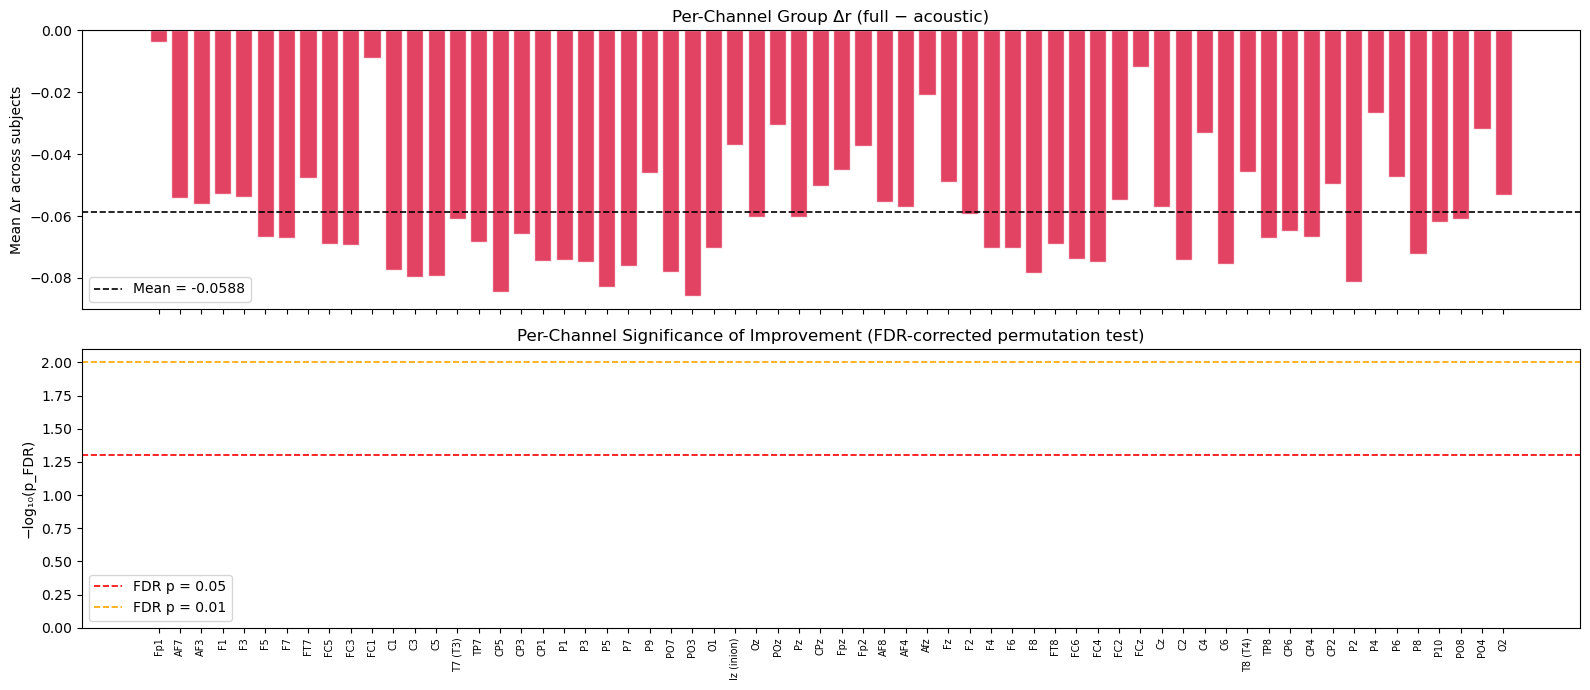

In [ ]:
n_subjects = 1
pickle_folder = 'encoding_2026-07-06'
model = 'conv_nonlinear'

plot(n_subjects, pickle_folder, model)

  Sub01 loaded

Loaded 1 subjects, 64 channels each

Group-level permutation test (mean r across channels):
  p = 1.0000  ns
  Mean Δr = 0.0023 ± 0.0000 SEM
  Channels significant after FDR (p<0.05): 0 / 64


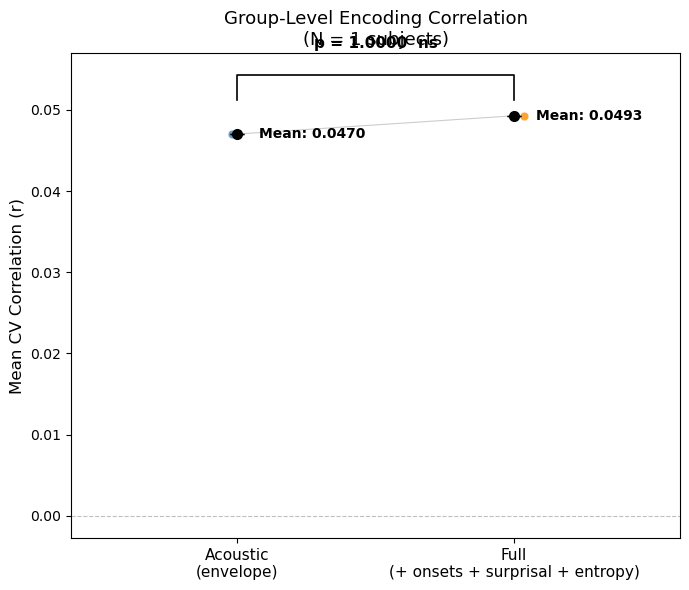

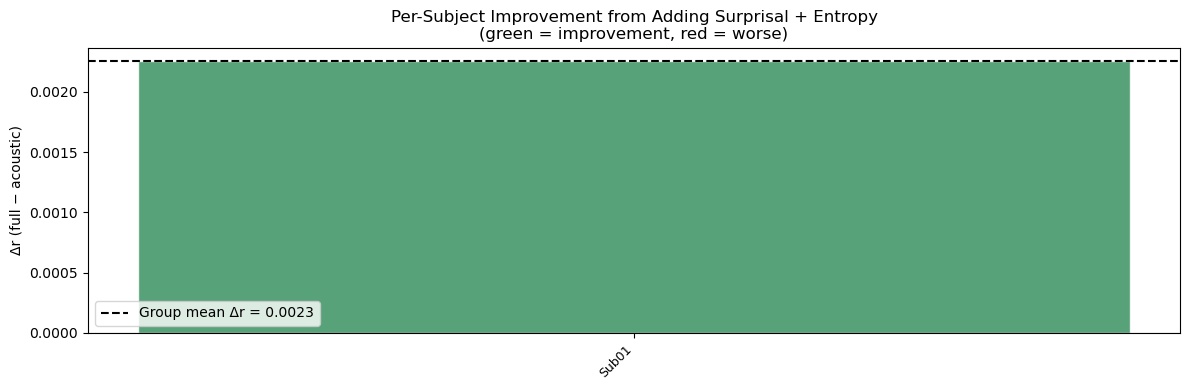

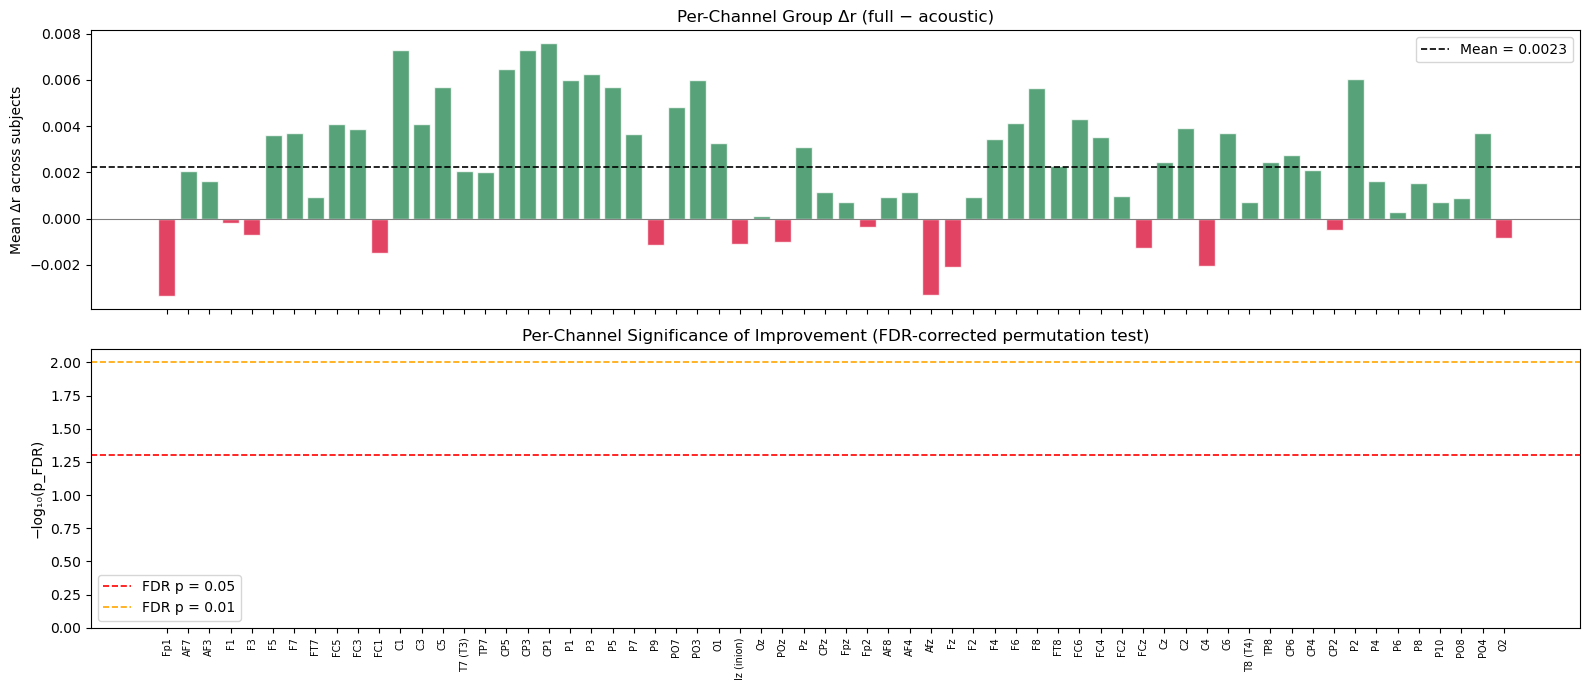

In [ ]:
n_subjects = 1
pickle_folder = 'encoding_2026-07-06'
model = 'mne_ridge'

plot(n_subjects, pickle_folder, model)

In [ ]:
def plot_across_models(n_subjects=None, pickle_folder=None, models=None):
    """
    Create a single figure showing side-by-side violins of mean CV correlation
    (acoustic vs full) for multiple models.
    """
    if n_subjects is None:
        n_subjects = globals().get('n_subjects', 1)
    if pickle_folder is None:
        pickle_folder = globals().get('pickle_folder', '')
    if models is None:
        models = ['boosting', 'sklearn_ridge', 'mne_ridge', 'conv_nonlinear']

    colors = ['steelblue', 'darkorange']
    fig, ax = plt.subplots(figsize=(12, 6))

    spacing = 3
    centers = []
    legend_handles = [
        Patch(facecolor=colors[0], edgecolor='none', label='Acoustic (envelope)'),
        Patch(facecolor=colors[1], edgecolor='none', label='Full (+ onsets + surprisal + entropy)')
    ]

    for i, model_name in enumerate(models):
        r_acoustic_all = []
        r_full_all = []

        for sub in range(1, n_subjects + 1):
            try:
                a = eelbrain.load.unpickle(f"results/{pickle_folder}/Sub{sub}__{model_name}__acoustic.pkl")
                f = eelbrain.load.unpickle(f"results/{pickle_folder}/Sub{sub}__{model_name}__acoustic_and_surprisal.pkl")
                r_acoustic_all.append(a['r_per_channel'])
                r_full_all.append(f['r_per_channel'])
            except FileNotFoundError:
                # skip missing subjects for this model
                continue

        if len(r_acoustic_all) == 0:
            continue

        r_acoustic_all = np.array(r_acoustic_all)
        r_full_all = np.array(r_full_all)
        r_acoustic_per_sub = r_acoustic_all.mean(axis=1)
        r_full_per_sub = r_full_all.mean(axis=1)

        base = i * spacing
        pos = [base + 1, base + 2]
        centers.append((pos[0] + pos[1]) / 2)

        parts = ax.violinplot([r_acoustic_per_sub, r_full_per_sub],
                              positions=pos, showmedians=False, showextrema=False)
        for pc, color in zip(parts['bodies'], colors):
            pc.set_facecolor(color)
            pc.set_alpha(0.6)

        # connect paired subject points within this model
        for j in range(len(r_acoustic_per_sub)):
            ax.plot([pos[0], pos[1]],
                    [r_acoustic_per_sub[j], r_full_per_sub[j]],
                    color='gray', alpha=0.4, linewidth=0.7)

        # scatter with jitter
        jitter = np.random.uniform(-0.04, 0.04, size=len(r_acoustic_per_sub))
        ax.scatter(np.full(len(r_acoustic_per_sub), pos[0]) + jitter, r_acoustic_per_sub,
                   color=colors[0], edgecolors='white', linewidths=0.5, s=40, alpha=0.8, zorder=4)
        jitter = np.random.uniform(-0.04, 0.04, size=len(r_full_per_sub))
        ax.scatter(np.full(len(r_full_per_sub), pos[1]) + jitter, r_full_per_sub,
                   color=colors[1], edgecolors='white', linewidths=0.5, s=40, alpha=0.8, zorder=4)

        # mean ± SEM markers
        for k, d in enumerate([r_acoustic_per_sub, r_full_per_sub], start=0):
            mean_val = d.mean()
            sem = d.std() / np.sqrt(len(d))
            ax.errorbar(pos[k], mean_val, yerr=sem, fmt='o', color='black',
                        markersize=6, capsize=4, linewidth=1.5, zorder=5)

        # optional: compute and display p-value for this model
        try:
            mean_diff, p_val = permutation_test(r_acoustic_per_sub, r_full_per_sub,
                                                n_permutations=10000, two_tailed=True)
            sig_label = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
            y_bracket = max(r_acoustic_per_sub.max(), r_full_per_sub.max()) + 0.005
            ax.plot([pos[0], pos[0], pos[1], pos[1]],
                    [y_bracket - 0.003, y_bracket, y_bracket, y_bracket - 0.003],
                    color='black', linewidth=1.0)
            ax.text((pos[0] + pos[1]) / 2, y_bracket + 0.003, f'p={p_val:.3f} {sig_label}',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
        except Exception:
            pass

    ax.set_xticks(centers)
    ax.set_xticklabels(models, fontsize=11)
    ax.set_xlim(-0.5, spacing * len(models) - 0.5)
    ax.set_ylabel('Mean CV Correlation (r)', fontsize=12)
    ax.set_title(f'Comparison across models (N subjects per model shown)', fontsize=13)
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)

    ax.legend(handles=legend_handles, loc='upper left')
    plt.tight_layout()
    plt.show()

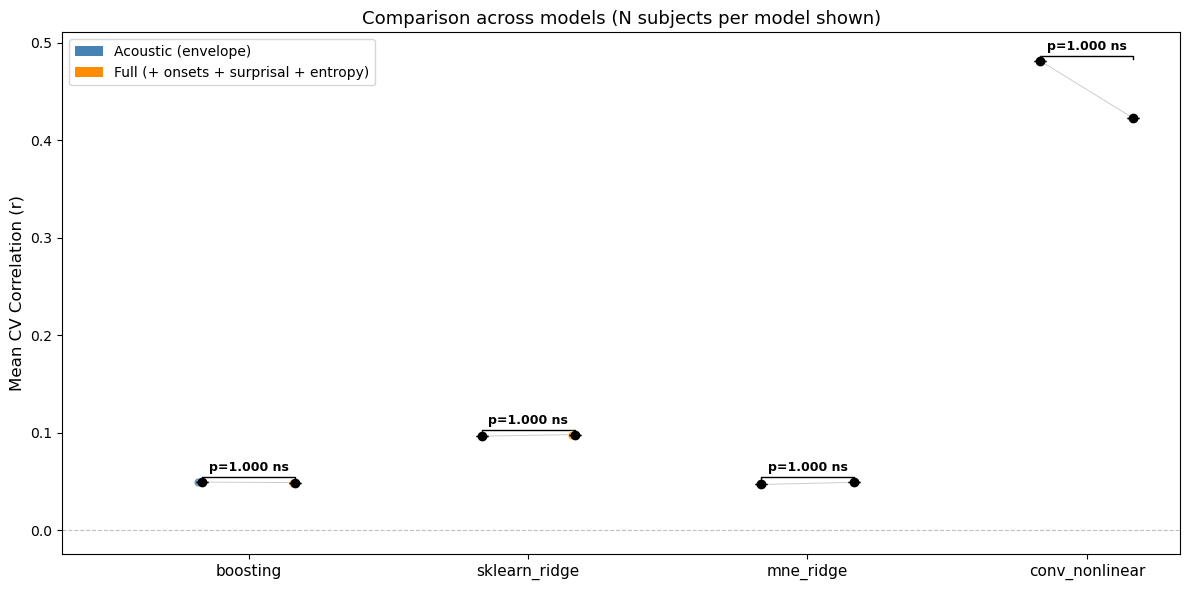

In [ ]:
n_subjects = 1
pickle_folder = 'encoding_2026-07-06'

plot_across_models(n_subjects=n_subjects, pickle_folder=pickle_folder, models=None)

/var/folders/r4/z65_5ryn59z3_3lyzgvxdcm40000gn/T/ipykernel_42687/1671435972.py:10: RuntimeWarning: Physical range is not defined in following channels:
sams_valence, sams_arousal, sams_valencert, sams_arousalrt, nback_stimuli, nback_keypress
  raw = mne.io.read_raw_edf(str(path), preload=True, verbose=False)


<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, Fp2, F3, F4, C3, C4, P3, P4, O1, O2, F7, F8, T7, T8, P7, ...
 chs: 46 EEG, 1 Stimulus
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 500.0 Hz
 meas_date: 2020-04-17 08:47:54 UTC
 nchan: 47
 projs: []
 sfreq: 1000.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: Anonymous, birthday: 1951-05-13>
>
n_channels=47, sfreq=1000.0, duration=1915.00s
channels: ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T7', 'T8', 'P7', 'P8', 'Fz', 'Cz', 'Pz', 'Oz', 'FC1', 'FC2', 'CP1', 'CP2', 'FC5', 'FC6', 'CP5', 'CP6', 'TP9', 'TP10', 'POz', 'ECG', 'ft_valance', 'ft_arousal', 'ft_x', 'ft_y', 'ft_ghostvalence', 'ft_ghostarousal', 'music', 'trialtype', 'sams_valence', 'sams_arousal', 'sams_valencert', 'sams_arousalrt', 'nback_stimuli', 'nback_keypress']


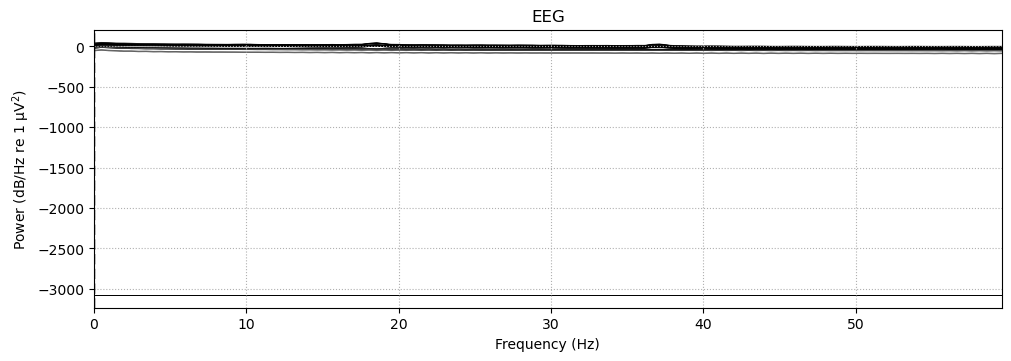

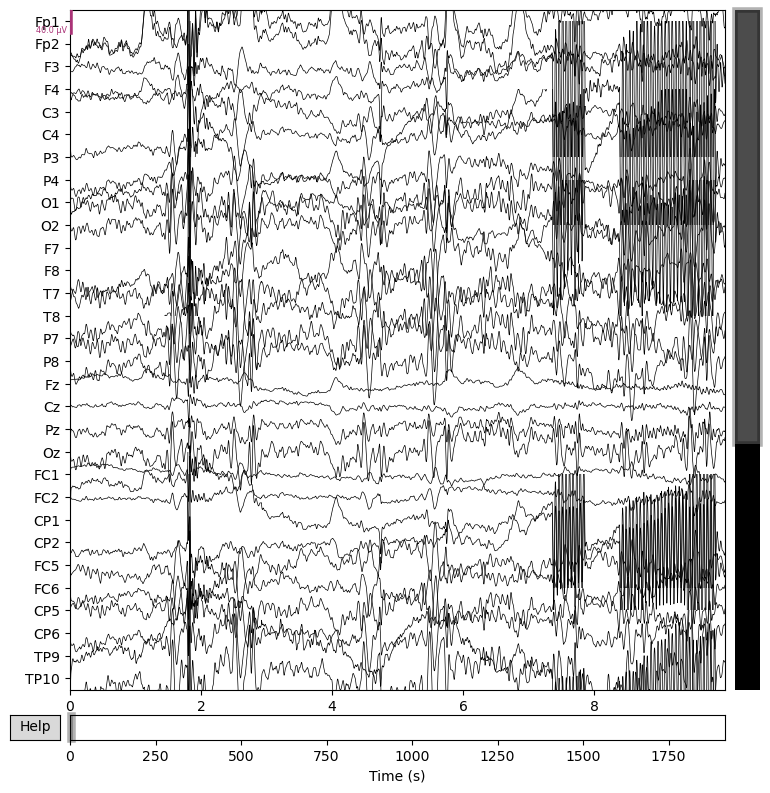

/var/folders/r4/z65_5ryn59z3_3lyzgvxdcm40000gn/T/ipykernel_42687/1671435972.py:19: UserWarning: Zero value in spectrum for channels sams_valence, sams_arousal, sams_valencert, sams_arousalrt, nback_stimuli, nback_keypress
  raw.plot_psd(fmax=min(60, raw.info['sfreq']/2))
/var/folders/r4/z65_5ryn59z3_3lyzgvxdcm40000gn/T/ipykernel_42687/1671435972.py:19: UserWarning: Infinite value in PSD for channels sams_valence, sams_arousal, sams_valencert, sams_arousalrt, nback_stimuli, nback_keypress.
These channels might be dead.
  raw.plot_psd(fmax=min(60, raw.info['sfreq']/2))
/var/folders/r4/z65_5ryn59z3_3lyzgvxdcm40000gn/T/ipykernel_42687/1671435972.py:19: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw.plot_psd(fmax=min(60, raw.info['sfreq']/2))
/Users/arianapereira/miniconda3/envs/eelbrain-env/lib/python3.11/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


In [ ]:
from pathlib import Path
import mne
import pyedflib
import numpy as np

edf_path = Path("datasets/daly_dataset/datalad/ds002725-1.0.0/sub-01/eeg/sub-01_task-classicalMusic_eeg.edf")

def view_edf(path: Path):
    try:
        raw = mne.io.read_raw_edf(str(path), preload=True, verbose=False)
        print(raw.info)
        print(f"n_channels={raw.info['nchan']}, sfreq={raw.info['sfreq']}, "
              f"duration={raw.n_times/raw.info['sfreq']:.2f}s")
        print("channels:", raw.ch_names[:46])
        if len(raw.annotations) > 0:
            print("annotations:", raw.annotations)
        # interactive browser-style plot (works in notebook)
        raw.plot(n_channels=min(30, raw.info['nchan']), title=path.name)
        raw.plot_psd(fmax=min(60, raw.info['sfreq']/2))
        return raw
    except Exception:
        pass

    # Fallback to pyedflib if mne is not available
    try:

        import matplotlib.pyplot as plt

        f = pyedflib.EdfReader(str(path))
        n = f.signals_in_file
        labels = f.getSignalLabels()
        fs = [f.getSampleFrequency(i) for i in range(n)]
        nsamples = f.getNSamples()
        print(f"signals_in_file={n}")
        print("labels:", labels[:30])
        print("sample rates (first 10):", fs[:10])
        print("n_samples (first 10):", nsamples[:10])

        # read up to first 8 channels for quick inspect
        nch = min(8, n)
        signals = np.vstack([f.readSignal(i) for i in range(nch)])
        t = np.arange(signals.shape[1]) / fs[0]

        plt.figure(figsize=(12, 6))
        offset = np.max(np.abs(signals)) * 1.5
        for i in range(nch):
            plt.plot(t, signals[i] + i * offset, label=labels[i])
        plt.xlabel("Time (s)")
        plt.title(path.name)
        plt.yticks([])
        plt.legend(loc="upper right")
        plt.tight_layout()
        plt.show()

        f.close()
        return signals
    except Exception as e:
        raise RuntimeError("Failed to read EDF file: install mne or pyedflib") from e

# call viewer
_view = view_edf(edf_path)

In [ ]:

raw = mne.io.read_raw_edf(str(edf_path), preload=True, verbose=False)
raw


/var/folders/r4/z65_5ryn59z3_3lyzgvxdcm40000gn/T/ipykernel_42687/2078302181.py:1: RuntimeWarning: Physical range is not defined in following channels:
sams_valence, sams_arousal, sams_valencert, sams_arousalrt, nback_stimuli, nback_keypress
  raw = mne.io.read_raw_edf(str(edf_path), preload=True, verbose=False)


<RawEDF | sub-01_task-classicalMusic_eeg.edf, 47 x 1915000 (1915.0 s), ~686.7 MiB, data loaded>

In [ ]:
raw['trialtype']

(array([[0., 0., 0., ..., 0., 0., 0.]], shape=(1, 1915000)),
 array([0.000000e+00, 1.000000e-03, 2.000000e-03, ..., 1.914997e+03,
        1.914998e+03, 1.914999e+03], shape=(1915000,)))

In [ ]:
raw['music'][0]

array([[0., 0., 0., ..., 0., 0., 0.]], shape=(1, 1915000))